<a href="https://colab.research.google.com/github/gitmystuff/DTSC5502/blob/main/Module_09-Feature_Selection/The_Titanic_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Selection with the Titanic

Name

## Getting Started

* Colab - get notebook from gitmystuff DTSC5502 repository
* Save a Copy in Drive
* Remove Copy of
* Edit name
* Take attendance
* Clean up Colab Notebooks folder
* Submit shared link

## The Story

* https://www.youtube.com/watch?v=ZPy-wg6ykJ0




### The Crystal Palace

The Great Exhibition of 1851

https://en.wikipedia.org/wiki/The_Crystal_Palace



### The Titanic - The Crystal Palace of the Sea

https://www.reddit.com/r/titanic/comments/mp1t32/this_is_one_of_my_favorite_shots_of_the_titanic/



### Ship Comparisons

https://www.hmy.com/timeline-worlds-largest-passenger-ships/



### Some Reads

On that fatal night in 1912, the world’s largest moving object disappeared beneath the waters of the North Atlantic in less than three hours. Why was the ship sailing through waters well known to be a "mass of floating ice"? Why were there too few lifeboats? Why were a third of the survivors crew members? Based on the sensational evidence of the U.S. Senate hearings, eyewitness accounts, and the results of the 1985 Woods Hole expedition that photographed the ship, this electrifying account vividly re-creates the vessel’s last desperate hours afloat and fully addresses the questions that have continued to haunt the tragedy of the Titanic.

**The Titanic: Disaster of the Century** by Wyn Craig Wade

Everyone from suffragists to their opponents; radicals, reformers, and capitalists; critics of technology and modern life; racists and xenophobes and champions of racial and ethnic equality; editorial writers and folk singers, preachers and poets found moral and cultural lessons in the sinking of the Titanic.

In a new edition that both commemorates the one hundredth anniversary of the disaster and elaborates, in a revised afterword, on the ship's continued impact on the public imagination (evidenced by the Titanic mania evoked by James Cameron's 1997 film), Steven Biel explores the Titanic in all its complexity and contradictions.

**Down with the Old Canoe: A Cultural History of the Titanic Disaster** by Steven Biel (Author)



### Early 1900s

* Ultranationalism
* Race Problem
* Equal Rights Problem
* Labor Problem
* Immigration Problem
* Rumors of War
* Spanish Flu



### Sources and Readings

* https://towardsdatascience.com/powerful-one-liners-in-pandas-every-data-scientist-should-know-737e721b81b6
* https://www.quora.com/What-kind-of-statistics-should-be-learned-to-make-a-good-data-analyst
* https://towardsdatascience.com/understanding-train-test-split-scikit-learn-python-ea676d5e3d1
* https://towardsdatascience.com/8-seaborn-plots-for-univariate-exploratory-data-analysis-eda-in-python-9d280b6fe67f
* https://www.encyclopedia-titanica.org/
* https://www.encyclopedia-titanica.org/class-gender-titanic-disaster-1912~chapter-2~part-2.html
* https://github.com/davidjamesknight/SQLite_databases_for_learning_data_science
* the Titanic dataset is from https://data.world/datasets/titanic-dataset

# Feature Selection

* https://colab.research.google.com/github/gitmystuff/DSChunks/blob/main/Feature_Selection_Methods.ipynb
* https://towardsdatascience.com/the-power-of-ridge-regression-4281852a64d6
* https://www.datasciencesmachinelearning.com/2019/10/feature-selection-filter-method-wrapper.html

* Filter Methods: Uses metrics such as correlation
    * Correlation
    * Chi Square
    * ANOVA
    * Information Gain
* Wrapper Methods: Uses algorithms and stats to find optimal features
    * Forward Selection
    * Backward Selection
    * Stepwise Selection
* Embedded Methods: Selects features during model building
    * Lasso
    * Ridge
    * Elastic Net

For now
<pre>
lasso
ridge
elastinet
correlation
variance inflation factor
mutual information
chi square
variance threshold
select k best
select from model
recursive feature elimination
</pre>

In [1]:
# create seed
import random

# provide your student id as stud_id
my_id = 42
my_seed = random.seed(my_id)

In [2]:
# get database
!wget https://github.com/gitmystuff/Datasets/raw/main/titanic.db

--2024-10-19 15:33:30--  https://github.com/gitmystuff/Datasets/raw/main/titanic.db
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/gitmystuff/Datasets/main/titanic.db [following]
--2024-10-19 15:33:31--  https://raw.githubusercontent.com/gitmystuff/Datasets/main/titanic.db
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 118784 (116K) [application/octet-stream]
Saving to: ‘titanic.db.13’

titanic.db.13       100%[===================>] 116.00K  --.-KB/s    in 0.04s   

2024-10-19 15:33:31 (2.98 MB/s) - ‘titanic.db.13’ saved [118784/118784]



In [3]:
import sqlite3
import pandas as pd

db_connection = sqlite3.connect('titanic.db')

titanic = pd.read_sql_query('SELECT * FROM titanic', db_connection)
titanic = titanic.sample(frac=1, axis=1).reset_index(drop=True)
titanic.drop('id', axis=1, inplace=True)
print(titanic.shape)
print(titanic.info())
titanic.head()

(1310, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1310 entries, 0 to 1309
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   body       121 non-null    float64
 1   name       1309 non-null   object 
 2   embarked   1307 non-null   object 
 3   age        1046 non-null   float64
 4   boat       486 non-null    object 
 5   survived   1309 non-null   float64
 6   fare       1308 non-null   float64
 7   ticket     1309 non-null   object 
 8   pclass     1309 non-null   float64
 9   sex        1309 non-null   object 
 10  home_dest  745 non-null    object 
 11  cabin      295 non-null    object 
 12  sibsp      1309 non-null   float64
 13  parch      1309 non-null   float64
dtypes: float64(7), object(7)
memory usage: 143.4+ KB
None


,body,name,embarked,age,boat,survived,fare,ticket,pclass,sex,home_dest,cabin,sibsp,parch
0,NaN,"Allen, Miss. Elisabeth Walton",S,29.0000,2,1.0,211.3375,24160,1.0,female,"St Louis, MO",B5,0.0,0.0
1,NaN,"Allison, Master. Hudson Trevor",S,0.9167,11,1.0,151.5500,113781,1.0,male,"Montreal, PQ / Chesterville, ON",C22 C26,1.0,2.0
2,NaN,"Allison, Miss. Helen Loraine",S,2.0000,None,0.0,151.5500,113781,1.0,female,"Montreal, PQ / Chesterville, ON",C22 C26,1.0,2.0
3,135.0,"Allison, Mr. Hudson Joshua Creighton",S,30.0000,None,0.0,151.5500,113781,1.0,male,"Montreal, PQ / Chesterville, ON",C22 C26,1.0,2.0
4,NaN,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",S,25.0000,None,0.0,151.5500,113781,1.0,female,"Montreal, PQ / Chesterville, ON",C22 C26,1.0,2.0


In [4]:
# sample
titanic.sample(5)

,body,name,embarked,age,boat,survived,fare,ticket,pclass,sex,home_dest,cabin,sibsp,parch
358,NaN,"Bystrom, Mrs. (Karolina)",S,42.0,None,1.0,13.000,236852,2.0,female,"New York, NY",None,0.0,0.0
1169,32.0,"Saether, Mr. Simon Sivertsen",S,38.5,None,0.0,7.250,SOTON/O.Q. 3101262,3.0,male,None,None,0.0,0.0
89,NaN,"Davidson, Mr. Thornton",S,31.0,None,0.0,52.000,F.C. 12750,1.0,male,"Montreal, PQ",B71,1.0,0.0
1129,NaN,"Petterson, Mr. Johan Emil",S,25.0,None,0.0,7.775,347076,3.0,male,None,None,1.0,0.0
1269,NaN,"Vande Velde, Mr. Johannes Joseph",S,33.0,None,0.0,9.500,345780,3.0,male,None,None,0.0,0.0


## Data Prep

### Variable Types

* Numerical
* Text
* Discrete
* Temporal

In [5]:
# idendify categorical, continuous, discrete, and temporal data
categorical = [feat for feat in titanic.select_dtypes(include=['object']).columns]
numerical = titanic.select_dtypes(include=['int64', 'float64']).columns
temporal = [feat for feat in numerical if 'Yr' in feat or 'Year' in feat]
continuous = [feat for feat in numerical if feat not in temporal and feat not in ['Id', 'SalePrice']]
discrete = [feat for feat in continuous if len(titanic[feat].unique()) < 5]
continuous = [feat for feat in continuous if feat not in discrete]

print(f'Categorical Features: {len(categorical)}, {categorical}')
print(f'Numerical Features: {len(continuous)}, {continuous}')
print(f'Temporal Features: {len(temporal)}, {temporal}')
print(f'Discrete Features: {len(discrete)}, {discrete}')

Categorical Features: 7, ['name', 'embarked', 'boat', 'ticket', 'sex', 'home_dest', 'cabin']
Numerical Features: 5, ['body', 'age', 'fare', 'sibsp', 'parch']
Temporal Features: 0, []
Discrete Features: 2, ['survived', 'pclass']


In [6]:
# find nulls
titanic.isnull().sum()

,0
body,1189
name,1
embarked,3
age,264
boat,824
survived,1
fare,2
ticket,1
pclass,1
sex,1


In [7]:
# find index of blank row
titanic.index[titanic.isnull().all(1)]

Index([1309], dtype='int64')

In [8]:
titanic.loc[1309]

,1309
body,NaN
name,None
embarked,None
age,NaN
boat,None
survived,NaN
fare,NaN
ticket,None
pclass,NaN
sex,None


In [9]:
# delete row by index
titanic.drop(index=1309, inplace=True)

In [10]:
# find nulls
titanic.isnull().sum()

,0
body,1188
name,0
embarked,2
age,263
boat,823
survived,0
fare,1
ticket,0
pclass,0
sex,0


In [11]:
# observation for missing fare
titanic[titanic.fare.isnull()]

,body,name,embarked,age,boat,survived,fare,ticket,pclass,sex,home_dest,cabin,sibsp,parch
1225,261.0,"Storey, Mr. Thomas",S,60.5,None,0.0,NaN,3701,3.0,male,None,None,0.0,0.0


In [12]:
# average 3rd class fare
titanic[titanic.pclass==3.0].fare.mean()

13.302888700564973

In [13]:
# impute missing fare
titanic.fare.fillna(13, inplace=True)

<ipython-input-13-384144bcc038>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic.fare.fillna(13, inplace=True)


In [14]:
# observation for missing embarked
titanic[titanic.embarked.isnull()]

,body,name,embarked,age,boat,survived,fare,ticket,pclass,sex,home_dest,cabin,sibsp,parch
168,NaN,"Icard, Miss. Amelie",None,38.0,6,1.0,80.0,113572,1.0,female,None,B28,0.0,0.0
284,NaN,"Stone, Mrs. George Nelson (Martha Evelyn)",None,62.0,6,1.0,80.0,113572,1.0,female,"Cincinatti, OH",B28,0.0,0.0


In [15]:
titanic[titanic['name'].str.contains('Stone', na=False)]

,body,name,embarked,age,boat,survived,fare,ticket,pclass,sex,home_dest,cabin,sibsp,parch
275,NaN,"Spedden, Mrs. Frederic Oakley (Margaretta Corn...",C,40.0,3,1.0,134.5,16966,1.0,female,"Tuxedo Park, NY",E34,1.0,1.0
284,NaN,"Stone, Mrs. George Nelson (Martha Evelyn)",None,62.0,6,1.0,80.0,113572,1.0,female,"Cincinatti, OH",B28,0.0,0.0


In [16]:
titanic[titanic['cabin'] == 'B28']

,body,name,embarked,age,boat,survived,fare,ticket,pclass,sex,home_dest,cabin,sibsp,parch
168,NaN,"Icard, Miss. Amelie",None,38.0,6,1.0,80.0,113572,1.0,female,None,B28,0.0,0.0
284,NaN,"Stone, Mrs. George Nelson (Martha Evelyn)",None,62.0,6,1.0,80.0,113572,1.0,female,"Cincinatti, OH",B28,0.0,0.0


In [17]:
# https://www.encyclopedia-titanica.org/titanic-survivor/martha-evelyn-stone.html
titanic.embarked.fillna('S', inplace=True)

<ipython-input-17-539f170965f3>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic.embarked.fillna('S', inplace=True)


In [18]:
titanic.isnull().sum()

,0
body,1188
name,0
embarked,0
age,263
boat,823
survived,0
fare,0
ticket,0
pclass,0
sex,0


In [19]:
# work on replacing age
print('Mr.', titanic[(pd.isna(titanic['age'])) & titanic['name'].str.contains('Mr\.')].shape)
print('Dr.', titanic[(pd.isna(titanic['age'])) & titanic['name'].str.contains('Dr\.')].shape)
print('Ms.', titanic[(pd.isna(titanic['age'])) & titanic['name'].str.contains('Ms\.')].shape)
print('Mrs.', titanic[(pd.isna(titanic['age'])) & titanic['name'].str.contains('Mrs\.')].shape)
print('Miss', titanic[(pd.isna(titanic['age'])) & titanic['name'].str.contains('Miss\.')].shape)
print('Master', titanic[(pd.isna(titanic['age'])) & titanic['name'].str.contains('Master')].shape)

Mr. (176, 14)
Dr. (1, 14)
Ms. (1, 14)
Mrs. (27, 14)
Miss (50, 14)
Master (8, 14)


In [20]:
# lookup Titanic Wikipedia
titanic[(pd.isna(titanic['age'])) & titanic['name'].str.contains('Dr\.')] # 46

,body,name,embarked,age,boat,survived,fare,ticket,pclass,sex,home_dest,cabin,sibsp,parch
40,NaN,"Brewe, Dr. Arthur Jackson",C,NaN,None,0.0,39.6,112379,1.0,male,"Philadelphia, PA",None,0.0,0.0


In [21]:
titanic.at[40, 'age'] = 46

In [22]:
# lookup Titanic Wikipedia
titanic[(pd.isna(titanic['age'])) & titanic['name'].str.contains('Ms\.')] # 21

,body,name,embarked,age,boat,survived,fare,ticket,pclass,sex,home_dest,cabin,sibsp,parch
1076,NaN,"O'Donoghue, Ms. Bridget",Q,NaN,None,0.0,7.75,364856,3.0,female,None,None,0.0,0.0


In [23]:
titanic.at[1076, 'age'] = 21

In [24]:
cond1 = titanic['name'].str.contains('Master')
titanic.loc[cond1,'age'] = titanic.loc[cond1,'age'].fillna(titanic.loc[cond1,'age'].mean())

cond2 = titanic['name'].str.contains('Miss\.')
titanic.loc[cond2,'age'] = titanic.loc[cond2,'age'].fillna(titanic.loc[cond2,'age'].mean())

cond3 = titanic['name'].str.contains('Mrs\.')
titanic.loc[cond3,'age'] = titanic.loc[cond3,'age'].fillna(titanic.loc[cond3,'age'].mean())

cond4 = titanic['name'].str.contains('Mr\.')
titanic.loc[cond4,'age'] = titanic.loc[cond4,'age'].fillna(titanic.loc[cond4,'age'].mean())

In [25]:
# recheck null count
titanic.isnull().sum()

,0
body,1188
name,0
embarked,0
age,0
boat,823
survived,0
fare,0
ticket,0
pclass,0
sex,0


### PrepPy

* Report
* Application
  * constant features
  * quasi constants
  * duplicate rows
  * duplicate columns

In [26]:
# preppy
! git clone https://github.com/gitmystuff/preppy.git

from preppy.version import __version__
print(__version__)

fatal: destination path 'preppy' already exists and is not an empty directory.
PrepPy Version: 0.1.0


In [27]:
# check cardinality and duplicates
import preppy.utils as utils

consts = utils.functions.identify_consts(titanic)
print('constants:', consts)

quasi_consts = utils.functions.identify_quasi_consts(titanic)
print('quasi constants:', quasi_consts)

print('duplicate rows:', utils.functions.check_row_duplicates(titanic))

duplicate_features = utils.functions.check_col_duplicates(titanic)
print('duplicate features:', duplicate_features)

constants: []
quasi constants: []
duplicate rows: 0
duplicate features: []


## Exploratory Data Analysis

In [28]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
                                titanic.drop(['survived'], axis=1),
                                titanic['survived'],
                                test_size=0.25,
                                random_state=42)

print(X_train.shape)
print(X_test.shape)
print(X_train.info())
print(X_train.head())

(981, 13)
(328, 13)
<class 'pandas.core.frame.DataFrame'>
Index: 981 entries, 1139 to 1126
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   body       93 non-null     float64
 1   name       981 non-null    object 
 2   embarked   981 non-null    object 
 3   age        981 non-null    float64
 4   boat       349 non-null    object 
 5   fare       981 non-null    float64
 6   ticket     981 non-null    object 
 7   pclass     981 non-null    float64
 8   sex        981 non-null    object 
 9   home_dest  554 non-null    object 
 10  cabin      219 non-null    object 
 11  sibsp      981 non-null    float64
 12  parch      981 non-null    float64
dtypes: float64(6), object(7)
memory usage: 107.3+ KB
None
      body                         name embarked   age  boat      fare  \
1139   NaN              Rekic, Mr. Tido        S  38.0  None    7.8958   
678    NaN         Boulos, Master. Akar        C   6.0  None   15.245

In [29]:
X_train.describe()

,body,age,fare,pclass,sibsp,parch
count,93.000000,981.000000,981.000000,981.000000,981.000000,981.000000
mean,161.709677,29.497520,33.665379,2.298675,0.531091,0.391437
std,99.157383,12.957128,52.467453,0.838785,1.066322,0.904461
min,1.000000,0.166700,0.000000,1.000000,0.000000,0.000000
25%,75.000000,21.774207,7.925000,2.000000,0.000000,0.000000
50%,165.000000,30.000000,14.500000,3.000000,0.000000,0.000000
75%,256.000000,36.000000,31.275000,3.000000,1.000000,0.000000
max,328.000000,80.000000,512.329200,3.000000,8.000000,9.000000


### Describe Include Object

In [30]:
X_train.describe(include='object')

,name,embarked,boat,ticket,sex,home_dest,cabin
count,981,981,349,981,981,554,219
unique,980,3,24,736,2,303,154
top,"Connolly, Miss. Kate",S,13,CA. 2343,male,"New York, NY",G6
freq,2,689,32,9,633,47,5


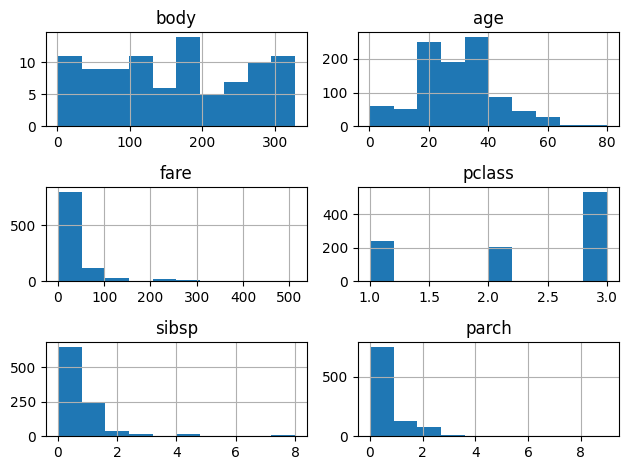

In [31]:
import matplotlib.pyplot as plt

X_train.hist()
plt.tight_layout();

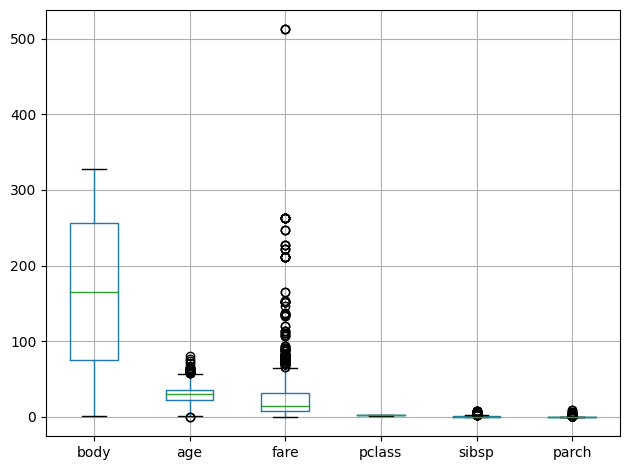

In [32]:
X_train.boxplot()
plt.tight_layout();

### Outliers

In [33]:
for feat in X_train._get_numeric_data().columns:
    q1 = X_train[feat].quantile(0.25)
    q3 = X_train[feat].quantile(0.75)
    iqr = q3 - q1
    lower_fence = (q1 - 1.5 * iqr).round()
    upper_fence = (q3 + 1.5 * iqr).round()
    lower_count = X_train[feat][X_train[feat] < lower_fence].count()
    upper_count = X_train[feat][X_train[feat] > upper_fence].count()
    if lower_count > 0 or upper_count > 0:
        print(f'{feat} outliers = {lower_count + upper_count}: lower_fence: {lower_fence}, upper_fence: {upper_fence}, lower_count: {lower_count}, upper_count: {upper_count}')

age outliers = 31: lower_fence: 0.0, upper_fence: 57.0, lower_count: 0, upper_count: 31
fare outliers = 129: lower_fence: -27.0, upper_fence: 66.0, lower_count: 0, upper_count: 129
sibsp outliers = 46: lower_fence: -2.0, upper_fence: 2.0, lower_count: 0, upper_count: 46
parch outliers = 228: lower_fence: 0.0, upper_fence: 0.0, lower_count: 0, upper_count: 228


<Axes: >

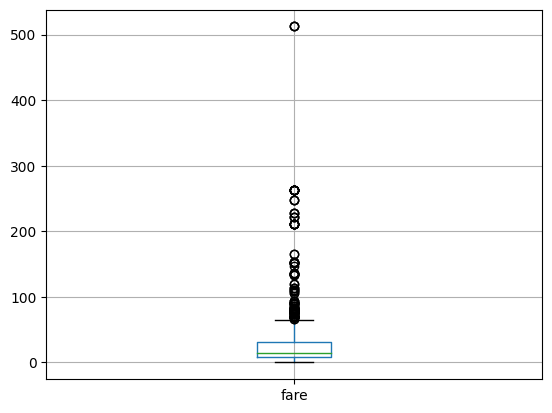

In [34]:
# use fare as an outlier example since it will be dropped anyway using boxplot
X_train.boxplot(column=['fare'])

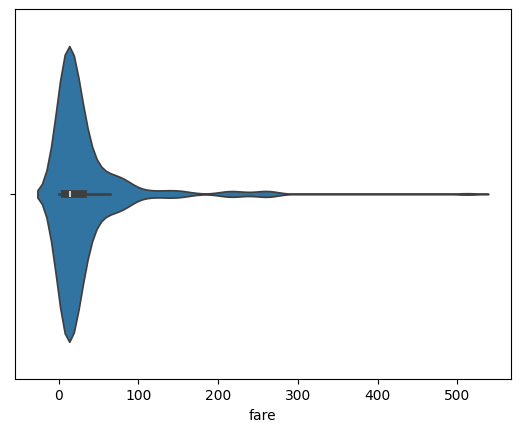

In [35]:
# fare violinplot
import seaborn as sns

sns.violinplot(x=X_train['fare']);

### Handling Outliers

https://www.projectpro.io/recipes/deal-with-outliers-in-python

* Drop
* Mark
* Rescale

### Scalers

https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html

* from sklearn.preprocessing import MinMaxScaler
* from sklearn.preprocessing import minmax_scale
* from sklearn.preprocessing import MaxAbsScaler
* from sklearn.preprocessing import StandardScaler
* from sklearn.preprocessing import RobustScaler
* from sklearn.preprocessing import Normalizer
* from sklearn.preprocessing import QuantileTransformer
* from sklearn.preprocessing import PowerTransformer

In [36]:
# PowerTransformer scaler for outliers
# from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import PowerTransformer

feat_scales = ['fare']

scaler = PowerTransformer()

for feat in feat_scales:
    X_train[feat] = scaler.fit_transform(X_train[feat].values.reshape(-1,1))

for feat in feat_scales:
    X_test[feat] = scaler.fit_transform(X_test[feat].values.reshape(-1,1))

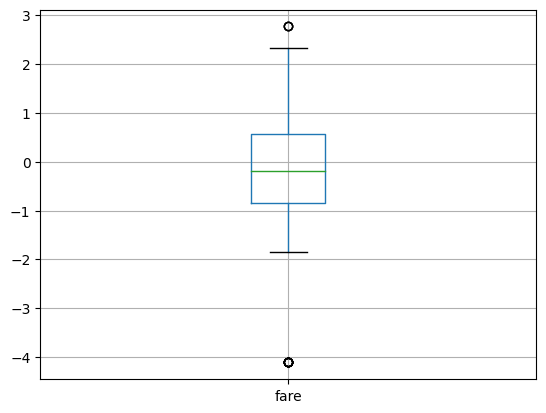

In [37]:
X_train.boxplot(column=['fare']);

In [38]:
X_train.describe()

,body,age,fare,pclass,sibsp,parch
count,93.000000,981.000000,9.810000e+02,981.000000,981.000000,981.000000
mean,161.709677,29.497520,-2.172914e-16,2.298675,0.531091,0.391437
std,99.157383,12.957128,1.000510e+00,0.838785,1.066322,0.904461
min,1.000000,0.166700,-4.107627e+00,1.000000,0.000000,0.000000
25%,75.000000,21.774207,-8.475775e-01,2.000000,0.000000,0.000000
50%,165.000000,30.000000,-1.988590e-01,3.000000,0.000000,0.000000
75%,256.000000,36.000000,5.746400e-01,3.000000,1.000000,0.000000
max,328.000000,80.000000,2.763854e+00,3.000000,8.000000,9.000000


In [39]:
for feat in X_train._get_numeric_data().columns:
    q1 = X_train[feat].quantile(0.25)
    q3 = X_train[feat].quantile(0.75)
    iqr = q3 - q1
    lower_fence = (q1 - 1.5 * iqr).round()
    upper_fence = (q3 + 1.5 * iqr).round()
    lower_count = X_train[feat][X_train[feat] < lower_fence].count()
    upper_count = X_train[feat][X_train[feat] > upper_fence].count()
    if lower_count > 0 or upper_count > 0:
        print(f'{feat} outliers = {lower_count + upper_count}: lower_fence: {lower_fence}, upper_fence: {upper_fence}, lower_count: {lower_count}, upper_count: {upper_count}')

age outliers = 31: lower_fence: 0.0, upper_fence: 57.0, lower_count: 0, upper_count: 31
fare outliers = 10: lower_fence: -3.0, upper_fence: 3.0, lower_count: 10, upper_count: 0
sibsp outliers = 46: lower_fence: -2.0, upper_fence: 2.0, lower_count: 0, upper_count: 46
parch outliers = 228: lower_fence: 0.0, upper_fence: 0.0, lower_count: 0, upper_count: 228


<Axes: >

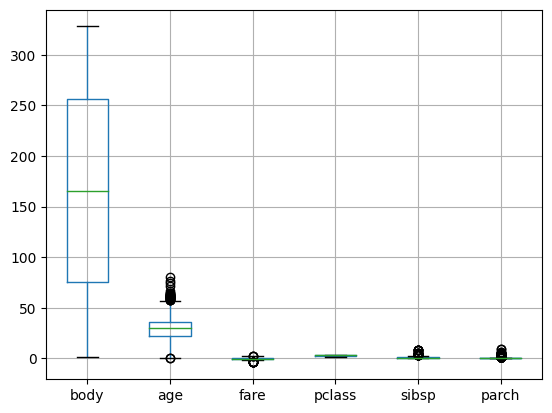

In [40]:
# show X_train boxplots
X_train.boxplot()

### Some Feature Engineering for EDA

In [41]:
# create adult male feature for demonstration
import pandas as pd

def is_adult_male(row):
    if pd.isna(row['age']):
        return None
    if row['age'] > 15 and row['age'] < 81 and row['sex'] == 'male':
        return 1
    else:
        return 0

X_train['adult_male'] = X_train.apply(is_adult_male, axis=1)
X_test['adult_male'] = X_test.apply(is_adult_male, axis=1) # whatever you do for X_train do for X_test except training
X_train['adult_male'].value_counts(dropna=False)

,count
adult_male,
1,582
0,399


In [42]:
# create embark_town
import pandas as pd

def set_embark_town(row):
    if pd.isna(row['age']):
        return None
    elif row['embarked'] == 'C':
        return 'Cherbourg'
    elif row['embarked'] == 'S':
        return 'Southampton'
    elif row['embarked'] == 'Q':
        return 'Queenstown'
    else:
        return None

X_train['embark_town'] = X_train.apply(set_embark_town, axis=1)
X_test['embark_town'] = X_test.apply(set_embark_town, axis=1) # whatever you do for X_train do for X_test except training
X_train['embark_town'].value_counts(dropna=False)

,count
embark_town,
Southampton,689
Cherbourg,197
Queenstown,95


In [43]:
titanic['home_dest'].isnull().sum()

564

In [44]:
# reducing labels
import numpy as np
import re

def cat_home(r):
    text = str(r['home_dest']).strip()
    if bool(re.search('[A-Z]{2}$', text[-2:])):
        return 'North America'
    elif text == 'None' or text =='':
        return 'Missing'
    else:
        return 'Not North America'

X_train['cat_home'] = X_train.apply(cat_home, axis=1)
X_test['cat_home'] = X_test.apply(cat_home, axis=1)

print(X_train['cat_home'].value_counts())

cat_home
Missing              427
North America        422
Not North America    132
Name: count, dtype: int64


In [45]:
# check info for categorical features
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 981 entries, 1139 to 1126
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   body         93 non-null     float64
 1   name         981 non-null    object 
 2   embarked     981 non-null    object 
 3   age          981 non-null    float64
 4   boat         349 non-null    object 
 5   fare         981 non-null    float64
 6   ticket       981 non-null    object 
 7   pclass       981 non-null    float64
 8   sex          981 non-null    object 
 9   home_dest    554 non-null    object 
 10  cabin        219 non-null    object 
 11  sibsp        981 non-null    float64
 12  parch        981 non-null    float64
 13  adult_male   981 non-null    int64  
 14  embark_town  981 non-null    object 
 15  cat_home     981 non-null    object 
dtypes: float64(6), int64(1), object(9)
memory usage: 130.3+ KB


In [46]:
# start list of features we won't use for analysis
drop_features = ['name', 'ticket', 'cabin', 'boat', 'body', 'home_dest', 'embarked']
X_train.drop(drop_features, axis=1).info() # don't want to make the drop features permanent right now

<class 'pandas.core.frame.DataFrame'>
Index: 981 entries, 1139 to 1126
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          981 non-null    float64
 1   fare         981 non-null    float64
 2   pclass       981 non-null    float64
 3   sex          981 non-null    object 
 4   sibsp        981 non-null    float64
 5   parch        981 non-null    float64
 6   adult_male   981 non-null    int64  
 7   embark_town  981 non-null    object 
 8   cat_home     981 non-null    object 
dtypes: float64(5), int64(1), object(3)
memory usage: 76.6+ KB


# Chi-Square Test

Gemini, October 19 2024
 Chi-square tests are very useful for determining relationships between categorical features.

**1. Choose Categorical Features**

   Since chi-square tests work with categorical data, select relevant features from your dataset. Good candidates include:

   * `pclass`: Passenger class (already numerical, but represents categories)
   * `sex`: Passenger gender
   * `embark_town`:  Port of embarkation (more detailed than `embarked`)

**2. Create Contingency Tables**

   A contingency table shows the frequency distribution of two categorical variables.  You'll need to create these for each feature you want to test against your target variable (`survived`). Here's how using pandas:

   ```python
   import pandas as pd
   from scipy.stats import chi2_contingency

   # Assuming your data is in a DataFrame called 'df'
   contingency_table_sex = pd.crosstab(df['survived'], df['sex'])
   contingency_table_pclass = pd.crosstab(df['survived'], df['pclass'])
   # ... create tables for other features
   ```

**3. Perform the Chi-Square Test**

   Now, apply the `chi2_contingency` function to each table:

   ```python
   chi2, p_value, dof, expected = chi2_contingency(contingency_table_sex)
   print(f"Chi-square statistic for sex: {chi2}")
   print(f"P-value for sex: {p_value}")

   chi2, p_value, dof, expected = chi2_contingency(contingency_table_pclass)
   print(f"Chi-square statistic for pclass: {chi2}")
   print(f"P-value for pclass: {p_value}")
   # ... repeat for other features
   ```

**4. Interpret the Results**

   * **Chi-square statistic:** A higher value indicates a stronger association between the variables.
   * **P-value:**  A low p-value (typically below 0.05) suggests that the relationship between the feature and survival is statistically significant, meaning it's unlikely to be due to random chance.

**5. Feature Selection**

   Based on the chi-square test results, you can rank the features by their association with survival. Features with higher chi-square statistics and lower p-values are likely to be more important predictors. You can then select the top-ranking features for your machine learning model.

**Example: Sex and Survival**

Let's say the chi-square test for `sex` gives you a very low p-value and a high chi-square statistic. This would strongly suggest that gender played a significant role in determining survival on the Titanic (which is historically accurate).

**Important Notes:**

* **Assumptions:** The chi-square test has some assumptions (e.g., expected frequencies in each cell of the contingency table should not be too low).
* **Correlation vs. Causation:** Remember that correlation doesn't imply causation. Even if a feature is strongly associated with survival, it doesn't necessarily mean it directly caused survival.
* **Other Techniques:** Chi-square is just one feature selection technique. Explore others like mutual information, ANOVA F-value, and recursive feature elimination for a more comprehensive analysis.


In [47]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 981 entries, 1139 to 1126
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   body         93 non-null     float64
 1   name         981 non-null    object 
 2   embarked     981 non-null    object 
 3   age          981 non-null    float64
 4   boat         349 non-null    object 
 5   fare         981 non-null    float64
 6   ticket       981 non-null    object 
 7   pclass       981 non-null    float64
 8   sex          981 non-null    object 
 9   home_dest    554 non-null    object 
 10  cabin        219 non-null    object 
 11  sibsp        981 non-null    float64
 12  parch        981 non-null    float64
 13  adult_male   981 non-null    int64  
 14  embark_town  981 non-null    object 
 15  cat_home     981 non-null    object 
dtypes: float64(6), int64(1), object(9)
memory usage: 130.3+ KB


In [48]:
import pandas as pd
from scipy.stats import chi2_contingency

for feat in ['sex', 'pclass', 'embark_town', 'cat_home']:
    contingency_table = pd.crosstab(y_train, X_train[feat])
    print(contingency_table)
    print()
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f"Chi-square statistic for {feat}: {chi2}")
    print(f"P-value for {feat}: {p_value}")
    print()

sex       female  male
survived              
0.0          104   521
1.0          244   112

Chi-square statistic for sex: 264.6318995204199
P-value for sex: 1.6784415091681463e-59

pclass    1.0  2.0  3.0
survived               
0.0        96  124  405
1.0       146   80  130

Chi-square statistic for pclass: 94.52053204654433
P-value for pclass: 2.9862574953324005e-21

embark_town  Cherbourg  Queenstown  Southampton
survived                                       
0.0                 89          64          472
1.0                108          31          217

Chi-square statistic for embark_town: 36.6660244477647
P-value for embark_town: 1.0916262098685877e-08

cat_home  Missing  North America  Not North America
survived                                           
0.0           319            216                 90
1.0           108            206                 42

Chi-square statistic for cat_home: 52.112023346881294
P-value for cat_home: 4.8307872325449235e-12



In [49]:
# mapping female male
X_train['sex'] = X_train['sex'].map({'female':0,'male':1})
X_test['sex'] = X_test['sex'].map({'female':0,'male':1})
X_train['sex'].value_counts()

,count
sex,
1,633
0,348


# Correlation

In [50]:
# show corr table
X_train.drop(drop_features, axis=1)._get_numeric_data().corr(method='pearson')

,age,fare,pclass,sex,sibsp,parch,adult_male
age,1.000000,0.125288,-0.351403,0.083373,-0.234017,-0.141657,0.267312
fare,0.125288,1.000000,-0.664885,-0.251469,0.327058,0.312213,-0.286963
pclass,-0.351403,-0.664885,1.000000,0.111668,0.062052,0.043457,0.062306
sex,0.083373,-0.251469,0.111668,1.000000,-0.120309,-0.228100,0.895494
sibsp,-0.234017,0.327058,0.062052,-0.120309,1.000000,0.360851,-0.272777
parch,-0.141657,0.312213,0.043457,-0.228100,0.360851,1.000000,-0.327840
adult_male,0.267312,-0.286963,0.062306,0.895494,-0.272777,-0.327840,1.000000


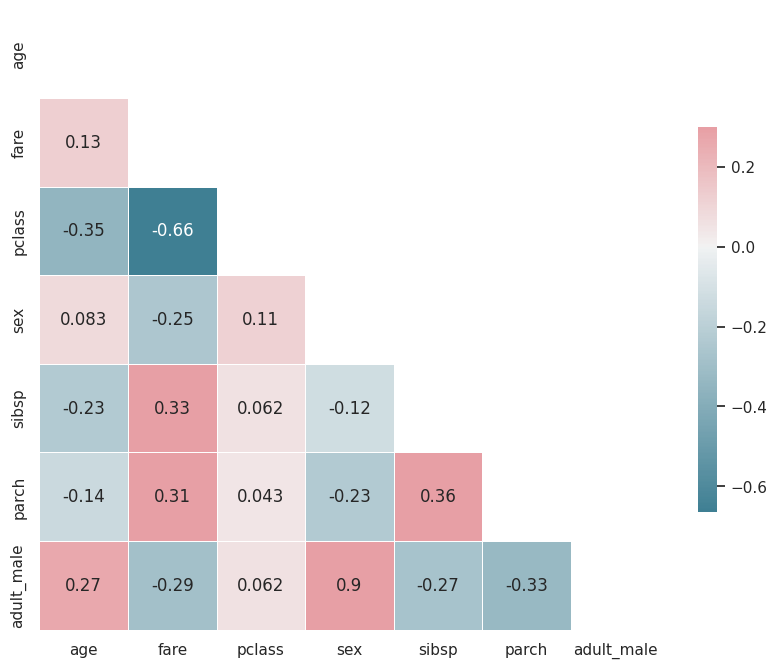

In [51]:
# feature on feature
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='white')

# compute the correlation matrix
corr = X_train.drop(drop_features, axis=1)._get_numeric_data().corr(method='pearson')

# generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# set up the matplotlib figure
f, ax = plt.subplots(figsize=(10,10))

# generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={'shrink': .5}, annot=True);

# Variance Inflation Factor

* Measures how much one predictor is influenced, or inflated, by the presence, or correlation, of another predictor
* Quick measure of the contribution of a predictor to the standard error, the standard deviation of a sample, in regression

https://www.statisticshowto.com/variance-inflation-factor/

In [52]:
# vif
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_train = X_train.drop(drop_features, axis=1)._get_numeric_data()
vif_data = [variance_inflation_factor(vif_train.values, i) for i in range(len(vif_train.columns))]

d = {'feature': vif_train.columns.values, 'vif': vif_data}
vif = pd.DataFrame(d)
vif

,feature,vif
0,age,5.256190
1,fare,2.020899
2,pclass,6.663489
3,sex,16.743011
4,sibsp,1.830951
5,parch,1.609142
6,adult_male,17.362679


In [53]:
# add adult_male to features to drop and possibly fare
# for a list, we use append to add one item and extend to add multiple items, or append another list
drop_features.extend(['adult_male', 'fare'])
drop_features

['name',
 'ticket',
 'cabin',
 'boat',
 'body',
 'home_dest',
 'embarked',
 'adult_male',
 'fare']

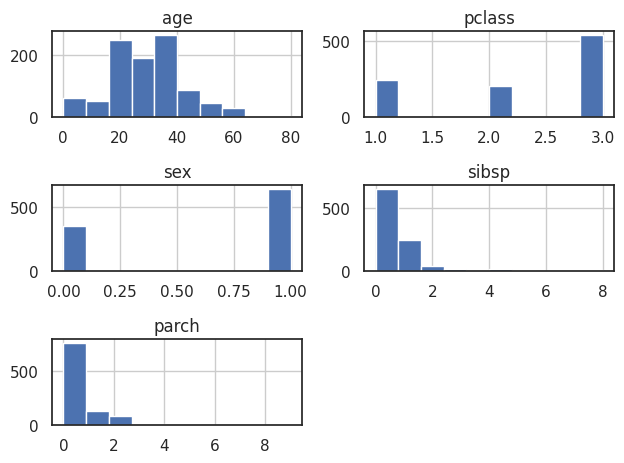

In [54]:
import matplotlib.pyplot as plt

X_train.drop(drop_features, axis=1)._get_numeric_data().hist()
plt.tight_layout();

## Tables and Plots

### Crosstab

ask Gemini what a crosstab is

In [55]:
pd.crosstab(X_train['cat_home'], X_train['pclass'])

pclass,1.0,2.0,3.0
cat_home,,,
Missing,27,13,387
North America,170,127,125
Not North America,45,64,23


<ipython-input-56-4551c08c0e9b>:4: FutureWarning: The provided callable <function mean at 0x78aa6e1f1000> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  result_crosstab = pd.crosstab(index = X_train['cat_home'],


<Axes: xlabel='pclass', ylabel='cat_home'>

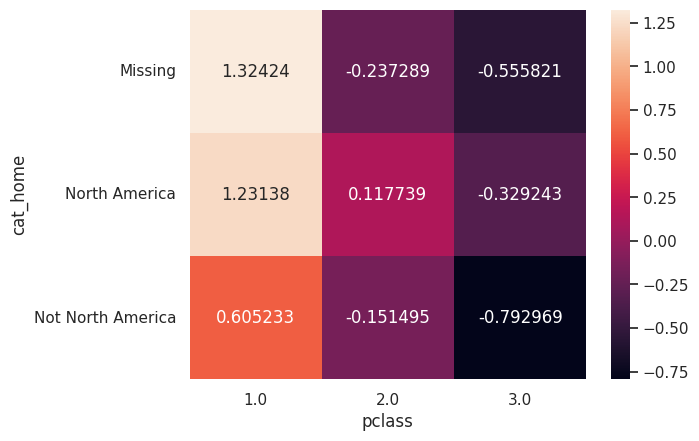

In [56]:
import numpy as np
import seaborn as sns

result_crosstab = pd.crosstab(index = X_train['cat_home'],
                              columns=X_train['pclass'],
                              values =X_train['fare'],
                              aggfunc=np.mean)

sns.heatmap(result_crosstab, annot = True, fmt = 'g')

### Pivot Table

ask Gemini what a pivot table is

In [57]:
pd.pivot_table(X_train,
               index=['cat_home'],
               columns=['pclass'],
               aggfunc='size',
               fill_value=0)

pclass,1.0,2.0,3.0
cat_home,,,
Missing,27,13,387
North America,170,127,125
Not North America,45,64,23


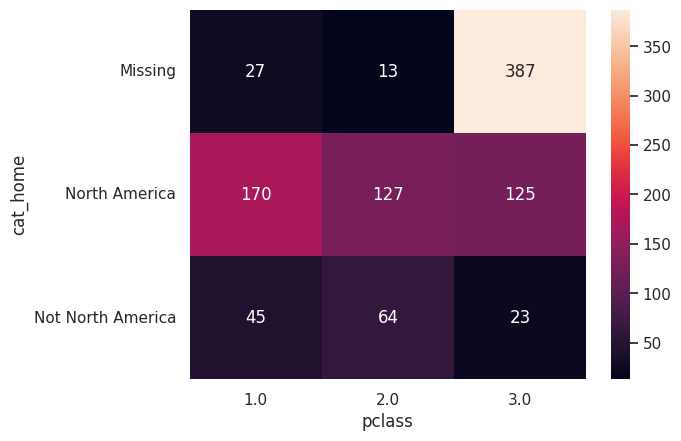

In [58]:
result_pivot = pd.pivot_table(X_train,
                              index=['cat_home'],
                              columns=['pclass'],
                              aggfunc='size',
                              fill_value=0)

sns.heatmap(result_pivot, annot = True, fmt = 'g');

### Rug Plot

A plot of data for a single quantitative variable, displayed as marks along an axis. It is used to visualise the distribution of the data. As such it is analogous to a histogram with zero-width bins, or a one-dimensional scatter plot.

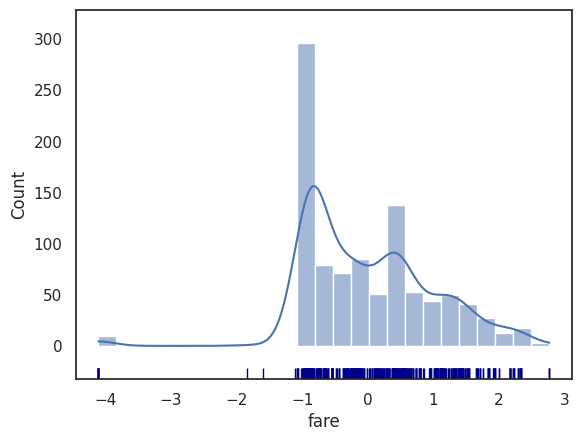

In [59]:
sns.rugplot(x='fare', data=X_train, height=.03, color='darkblue')
sns.histplot(x='fare', data=X_train, kde=True);

### Strip Plot

A strip plot can be drawn on its own, but it is also a good complement to a box or violin plot in cases where you want to show all observations along with some representation of the underlying distribution.

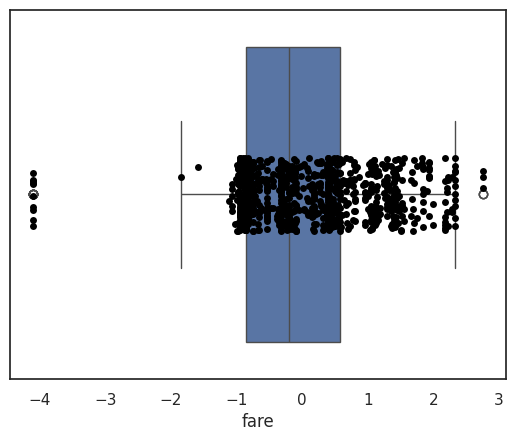

In [60]:
ax = sns.stripplot(x=X_train['fare'], dodge=True, color='black')
sns.boxplot(data=X_train, x='fare', ax=ax);

### Count Plot

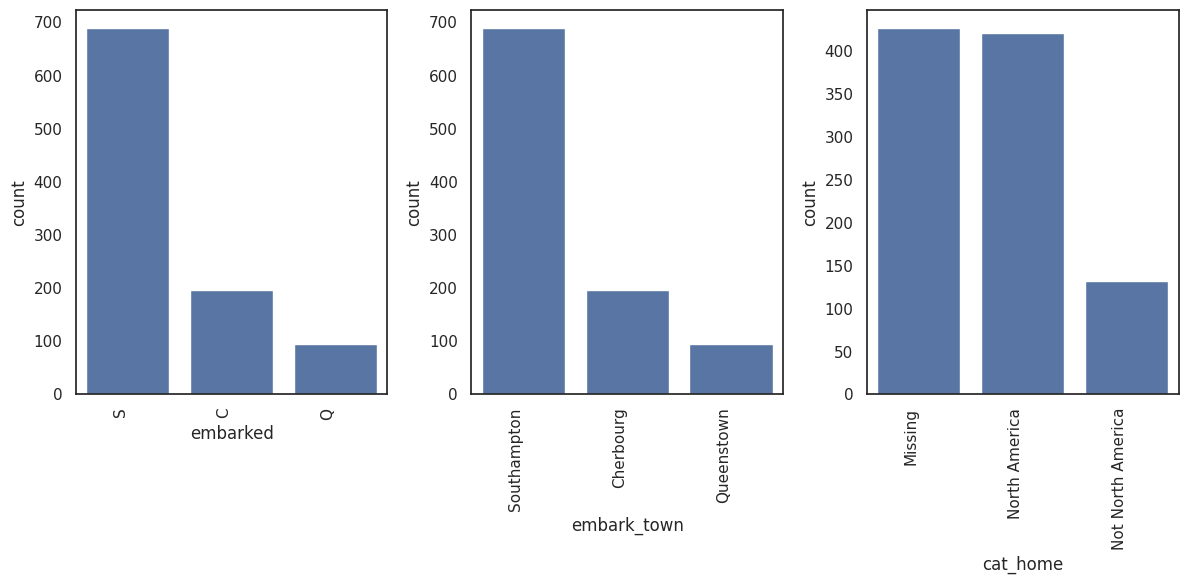

In [61]:
cols = 4
rows = 1
fig = plt.figure(figsize= (16,6))
all_cats = X_train.select_dtypes(include='object')
cat_cols = all_cats.columns[all_cats.nunique() < 10]
for i, col in enumerate(cat_cols):
    ax=fig.add_subplot(rows, cols, i+1)
    sns.countplot(x=X_train[col], ax=ax)
    plt.xticks(rotation=90, ha='right')

fig.tight_layout()
plt.show()

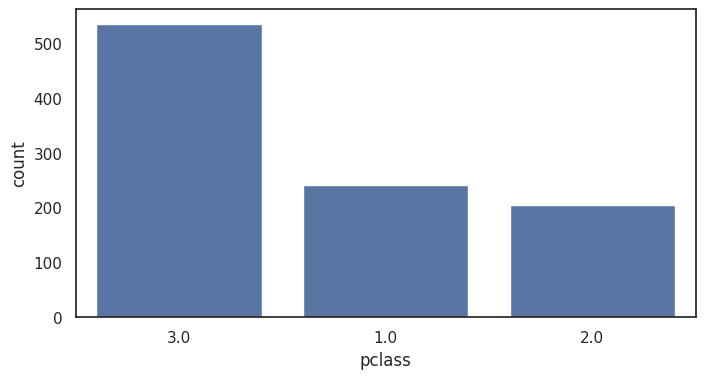

In [62]:
# look at pclass counts
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(x=X_train.pclass, order=X_train.pclass.value_counts().index);

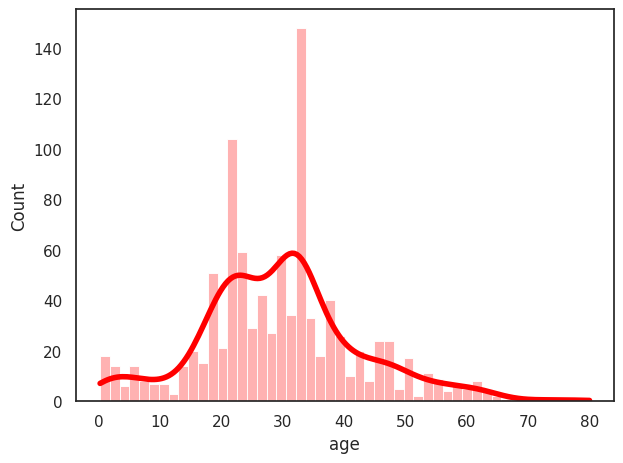

In [63]:
# example of a histogram with kde
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(X_train['age'], alpha=0.3, kde=True,
             bins=int(50), color = 'red',
             line_kws={'linewidth': 4})

plt.tight_layout()
plt.show();

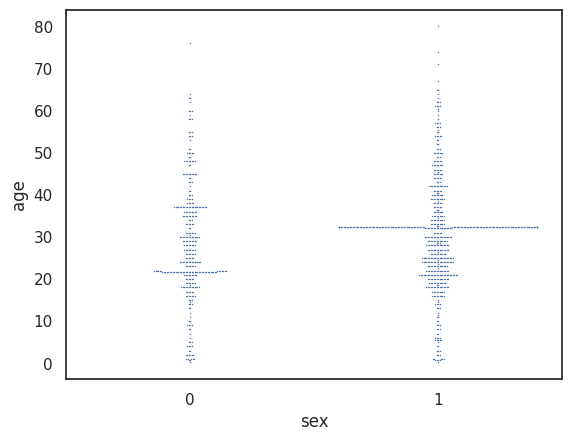

In [64]:
# an interesting way to view sex and age .map({'female':1,'male':0})
import seaborn as sns

sns.swarmplot(x='sex', y='age', data=X_train.drop(drop_features, axis=1)._get_numeric_data(), size=1);

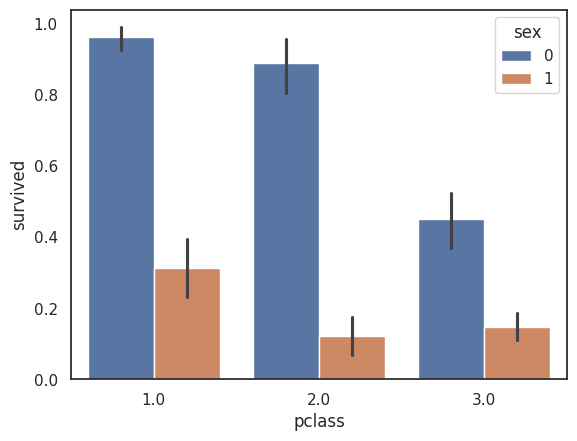

In [65]:
# bar chart with 95% confidence intervals (error bars)
sns.barplot(x='pclass', y=y_train, hue='sex', data=X_train);

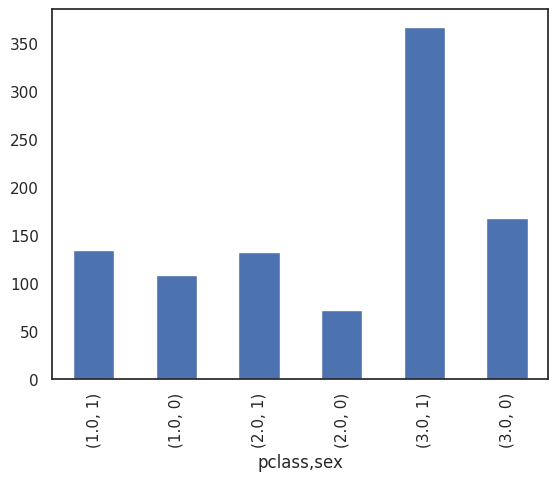

In [66]:
# example of using groupby
X_train.groupby('pclass')['sex'].value_counts().plot(kind='bar');

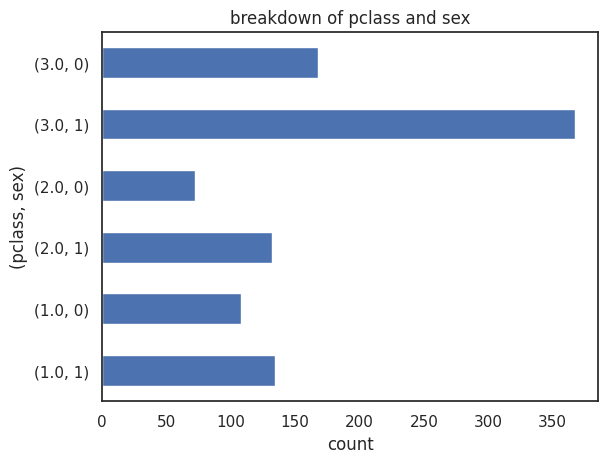

In [67]:
X_train.groupby('pclass')['sex'].value_counts().plot.barh()
plt.xlabel('count')
plt.ylabel('(pclass, sex)')
plt.title('breakdown of pclass and sex')
plt.show()

## Groupbys

https://towardsdatascience.com/11-simple-code-blocks-for-complete-exploratory-data-analysis-eda-67c2817f56cd

In [68]:
# groupby data views
X_train.groupby(['pclass', 'embark_town']).size()

pclass  embark_town
1.0     Cherbourg      102
        Queenstown       2
        Southampton    138
2.0     Cherbourg       20
        Queenstown       6
        Southampton    178
3.0     Cherbourg       75
        Queenstown      87
        Southampton    373
dtype: int64

In [69]:
# using aggregates
X_train.groupby('embark_town')['fare'].agg(['min', 'max', 'mean', 'median'])

,min,max,mean,median
embark_town,,,,
Cherbourg,-1.593478,2.763854,0.504036,0.457918
Queenstown,-1.023425,1.516572,-0.600189,-0.871993
Southampton,-4.107627,2.327027,-0.061360,-0.227622


### nlargest

* n = 6
* data.nlargest(n, 'fare, keep = 'all')

In [70]:
n = 6
X_train.nlargest(n, 'fare', keep='all')

,body,name,embarked,age,boat,fare,ticket,pclass,sex,home_dest,cabin,sibsp,parch,adult_male,embark_town,cat_home
183,NaN,"Lesurer, Mr. Gustave J",C,35.0,3,2.763854,PC 17755,1.0,1,None,B101,0.0,0.0,1,Cherbourg,Missing
302,NaN,"Ward, Miss. Anna",C,35.0,3,2.763854,PC 17755,1.0,0,None,None,0.0,0.0,0,Cherbourg,Missing
50,NaN,"Cardeza, Mrs. James Warburton Martinez (Charlo...",C,58.0,3,2.763854,PC 17755,1.0,0,"Germantown, Philadelphia, PA",B51 B53 B55,0.0,1.0,0,Cherbourg,North America
111,NaN,"Fortune, Miss. Alice Elizabeth",S,24.0,10,2.327027,19950,1.0,0,"Winnipeg, MB",C23 C25 C27,3.0,2.0,0,Southampton,North America
114,NaN,"Fortune, Mr. Charles Alexander",S,19.0,None,2.327027,19950,1.0,1,"Winnipeg, MB",C23 C25 C27,3.0,2.0,1,Southampton,North America
116,NaN,"Fortune, Mrs. Mark (Mary McDougald)",S,60.0,10,2.327027,19950,1.0,0,"Winnipeg, MB",C23 C25 C27,1.0,4.0,0,Southampton,North America
112,NaN,"Fortune, Miss. Ethel Flora",S,28.0,10,2.327027,19950,1.0,0,"Winnipeg, MB",C23 C25 C27,3.0,2.0,0,Southampton,North America


### nsmallest

* n = 7
* data.nsmallest(n, 'fare', keep = 'all')

In [71]:
n = 7
X_train.nsmallest(n, 'fare', keep='all')

,body,name,embarked,age,boat,fare,ticket,pclass,sex,home_dest,cabin,sibsp,parch,adult_male,embark_town,cat_home
581,NaN,"Watson, Mr. Ennis Hastings",S,32.252151,None,-4.107627,239856,2.0,1,Belfast,None,0.0,0.0,1,Southampton,Not North America
223,NaN,"Parr, Mr. William Henry Marsh",S,32.252151,None,-4.107627,112052,1.0,1,Belfast,None,0.0,0.0,1,Southampton,Not North America
7,NaN,"Andrews, Mr. Thomas Jr",S,39.000000,None,-4.107627,112050,1.0,1,"Belfast, NI",A36,0.0,0.0,1,Southampton,North America
898,NaN,"Johnson, Mr. William Cahoone Jr",S,19.000000,None,-4.107627,LINE,3.0,1,None,None,0.0,0.0,1,Southampton,Missing
125,NaN,"Fry, Mr. Richard",S,32.252151,None,-4.107627,112058,1.0,1,None,B102,0.0,0.0,1,Southampton,Missing
234,NaN,"Reuchlin, Jonkheer. John George",S,38.000000,None,-4.107627,19972,1.0,1,"Rotterdam, Netherlands",None,0.0,0.0,1,Southampton,Not North America
473,NaN,"Knight, Mr. Robert J",S,32.252151,None,-4.107627,239855,2.0,1,Belfast,None,0.0,0.0,1,Southampton,Not North America
896,NaN,"Johnson, Mr. Alfred",S,49.000000,None,-4.107627,LINE,3.0,1,None,None,0.0,0.0,1,Southampton,Missing
150,110.0,"Harrison, Mr. William",S,40.000000,None,-4.107627,112059,1.0,1,None,B94,0.0,0.0,1,Southampton,Missing
384,NaN,"Cunningham, Mr. Alfred Fleming",S,32.252151,None,-4.107627,239853,2.0,1,Belfast,None,0.0,0.0,1,Southampton,Not North America


In [72]:
# groupby data views
X_train.groupby(['pclass', 'embarked']).size()

pclass  embarked
1.0     C           102
        Q             2
        S           138
2.0     C            20
        Q             6
        S           178
3.0     C            75
        Q            87
        S           373
dtype: int64

## Feature Engineering

### Mapping Dependent Variable

* Label Encoder for labels in classification **target**
* Use LabelEncoder when there are only two possible values of a categorical **features**

### Multicollinearity

* Combine features with high multicollinearity
* Standardize both and then take the average of the two

### Bi Label Mapping

In [73]:
# identify features with bi labels
bi_labels = []
for feat in X_train.select_dtypes(include='object').columns.sort_values():
    if (len(X_train[feat].dropna().unique()) < 3):
        print(X_train[feat].value_counts())
        bi_labels.append(feat)

In [74]:
X_train['cat_home'].value_counts()

,count
cat_home,
Missing,427
North America,422
Not North America,132


In [75]:
# bi-label mapping

for feat in bi_labels:
    print(X_train[feat].value_counts())
    bi0 = X_train[feat].value_counts().index[0]
    bi1 = X_train[feat].value_counts().index[1]
    X_train[feat] = X_train[feat].map({bi0:0,bi1:1})
    X_test[feat] = X_test[feat].map({bi0:0,bi1:1})

X_train.head()

,body,name,embarked,age,boat,fare,ticket,pclass,sex,home_dest,cabin,sibsp,parch,adult_male,embark_town,cat_home
1139,NaN,"Rekic, Mr. Tido",S,38.0,None,-0.851612,349249,3.0,1,None,None,0.0,0.0,1,Southampton,Missing
678,NaN,"Boulos, Master. Akar",C,6.0,None,-0.146373,2678,3.0,1,"Syria Kent, ON",None,1.0,1.0,0,Cherbourg,North America
290,NaN,"Taussig, Mr. Emil",S,52.0,None,1.415151,110413,1.0,1,"New York, NY",E67,1.0,1.0,1,Southampton,North America
285,96.0,"Straus, Mr. Isidor",S,67.0,None,2.207414,PC 17483,1.0,1,"New York, NY",C55 C57,1.0,0.0,1,Southampton,North America
1157,NaN,"Rosblom, Mr. Viktor Richard",S,18.0,None,0.143786,370129,3.0,1,None,None,1.0,1.0,1,Southampton,Missing


### One Hot Encoding Alternatives

For features with many labels

* https://medium.com/analytics-vidhya/stop-one-hot-encoding-your-categorical-variables-bbb0fba89809
* https://medium.com/swlh/stop-one-hot-encoding-your-categorical-features-avoid-curse-of-dimensionality-16743c32cea4
* https://towardsdatascience.com/all-about-categorical-variable-encoding-305f3361fd02 (frequency and mean encoding)

In [76]:
# review features with multiple labels
# freq_feats = []
# for feat in X_train.columns.sort_values():
#     print(feat, len(X_train[feat].dropna().unique()))
#     if (len(X_train[feat].dropna().unique()) > 5):
#         freq_feats.append(feat)

In [77]:
# identify features with more than 5 features and use frequency encoding
# for feat in freq_feats:
#     freq = X_train.groupby(feat).size()/len(X_train)
#     X_train.loc[:, feat] = X_train[feat].map(freq)
#     freq = X_test.groupby(feat).size()/len(X_test)
#     X_test.loc[:, feat] = X_test[feat].map(freq)

### One Hot Encoding

In [78]:
X_train.drop(drop_features, axis=1).info()

<class 'pandas.core.frame.DataFrame'>
Index: 981 entries, 1139 to 1126
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          981 non-null    float64
 1   pclass       981 non-null    float64
 2   sex          981 non-null    int64  
 3   sibsp        981 non-null    float64
 4   parch        981 non-null    float64
 5   embark_town  981 non-null    object 
 6   cat_home     981 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 61.3+ KB


In [79]:
# use sklearn one hot encoder
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(categories='auto', drop='first', sparse_output=False, handle_unknown='ignore')

cat_features = ['embark_town', 'cat_home']
ohe_train = ohe.fit_transform(X_train[cat_features])
ohe_train = pd.DataFrame(ohe_train, columns=ohe.get_feature_names_out(cat_features))
ohe_train.index = X_train.index
X_train = X_train.join(ohe_train)
X_train.drop(cat_features, axis=1, inplace=True)

ohe_test = ohe.transform(X_test[cat_features])
ohe_test = pd.DataFrame(ohe_test, columns=ohe.get_feature_names_out(cat_features))
ohe_test.index = X_test.index
X_test = X_test.join(ohe_test)
X_test.drop(cat_features, axis=1, inplace=True)

print(X_train.drop(drop_features, axis=1).shape)
print(X_test.drop(drop_features, axis=1).shape)
print(X_train.drop(drop_features, axis=1).info())

(981, 9)
(328, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 981 entries, 1139 to 1126
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         981 non-null    float64
 1   pclass                      981 non-null    float64
 2   sex                         981 non-null    int64  
 3   sibsp                       981 non-null    float64
 4   parch                       981 non-null    float64
 5   embark_town_Queenstown      981 non-null    float64
 6   embark_town_Southampton     981 non-null    float64
 7   cat_home_North America      981 non-null    float64
 8   cat_home_Not North America  981 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 108.9 KB
None


Gemini, October 19 2024

* **Classification Problem:** You're trying to predict a categorical outcome (survived or not survived), making this a classification problem.
* **`mutual_info_classif`:** This function specifically estimates mutual information for a classification task. It measures the dependency between your features (age, pclass, sex, etc.) and the discrete target variable (survival).

**How `mutual_info_classif` helps:**

* **Captures Relationships:** It can identify both linear and non-linear relationships between features and survival. This is a key advantage over methods like `f_classif`, which primarily focus on linear relationships.
* **Feature Ranking:** By calculating mutual information scores, you can rank your features based on how strongly they are related to the target variable. Higher scores indicate more informative features.
* **Dimensionality Reduction:** You can use `SelectPercentile` (as you mentioned) to select a specific percentage of the top-ranked features, helping to reduce the dimensionality of your data and potentially improve model performance.

**Your code snippet looks good:**

```python
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectPercentile

mi = mutual_info_classif(X_train.drop(drop_features, axis=1), y_train)
```

This calculates the mutual information between each feature in your training data (`X_train` after dropping unnecessary features) and the target variable (`y_train`).

**Next Steps:**

1. **Examine MI Scores:** Analyze the `mi` values to see which features have the highest mutual information with survival.
2. **Select Features:** Use `SelectPercentile` to choose a subset of the most informative features based on a desired percentile.
3. **Build and Evaluate Models:**  Train your classification model (e.g., logistic regression, random forest) using the selected features and evaluate its performance.

By using `mutual_info_classif` and `SelectPercentile`, you're employing a powerful technique to identify and select the most relevant features for predicting survival on the Titanic.


## Feature Selection

* https://colab.research.google.com/github/gitmystuff/DSChunks/blob/main/Feature_Selection_Methods.ipynb
* https://towardsdatascience.com/the-power-of-ridge-regression-4281852a64d6
* https://www.datasciencesmachinelearning.com/2019/10/feature-selection-filter-method-wrapper.html

* Filter Methods: Uses metrics such as correlation
    * Correlation
    * Chi Square
    * ANOVA
    * Information Gain
* Wrapper Methods: Uses algorithms and stats to find optimal features
    * Forward Selection
    * Backward Selection
    * Stepwise Selection
* Embedded Methods: Selects features during model building
    * Lasso
    * Ridge
    * Elastic Net

For now
<pre>
lasso
ridge
elastinet
correlation
variance inflation factor
mutual information
chi square
variance threshold
select k best
select from model
recursive feature elimination
</pre>

### Lasso / l1 Regularization

* $\alpha = \sum|w_i|$
* Forces weak features to have zero coefficients
* Performs feature selection
* Models can be unstable (coefficients fluctuate significantly on data changes with correlated features)

In [80]:
# lasso example
# alpha https://scikit-learn.org/dev/modules/generated/sklearn.linear_model.Lasso.html
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X_train.drop(drop_features, axis=1))
y = y_train
names = X_train.drop(drop_features, axis=1).columns

lasso = Lasso(alpha=.05)
lasso.fit(X, y)

d = {'Feature': names, 'Coeff': lasso.coef_}
lasso_df = pd.DataFrame(d)
print(lasso_df[1:])

                      Feature     Coeff
1                      pclass -0.074957
2                         sex -0.191794
3                       sibsp -0.000000
4                       parch -0.000000
5      embark_town_Queenstown -0.000000
6     embark_town_Southampton -0.000000
7      cat_home_North America  0.005637
8  cat_home_Not North America -0.000000


### Mutual Information

* Measures the mutual dependence on two variables
* Persons r is linear where as MI measures non-linear relationships
* How much information can be extracted from one variable by observing another variable

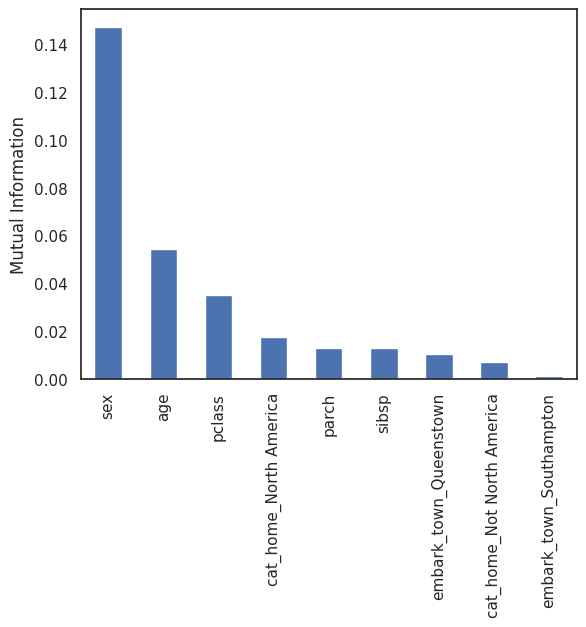

In [81]:
# obtain the mutual information values and select features
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.feature_selection import SelectPercentile

mi = mutual_info_classif(X_train.drop(drop_features, axis=1), y_train)
mi = pd.Series(mi)
mi.index = X_train.drop(drop_features, axis=1).columns
mi.sort_values(ascending=False).plot.bar()
plt.ylabel('Mutual Information');

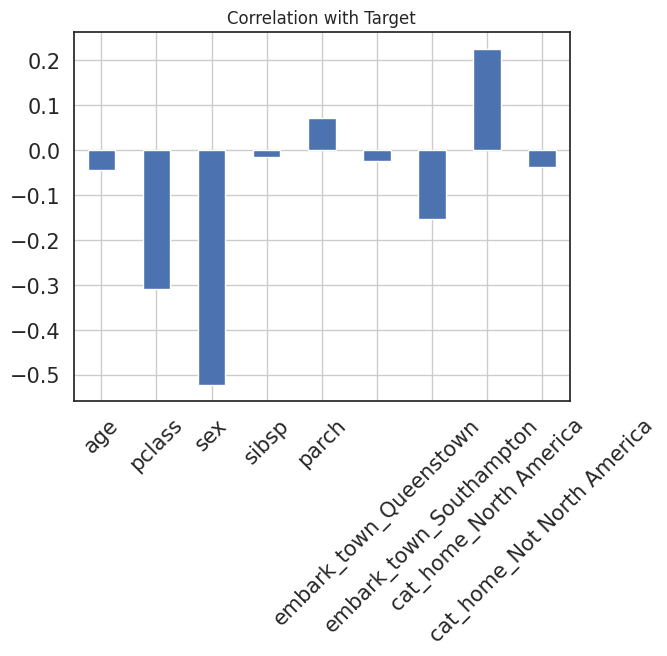

In [82]:
# correlation anlaysis against our titanic target (survived)
X_train.drop(drop_features, axis=1)._get_numeric_data().corrwith(y_train).plot.bar(
        title = "Correlation with Target", fontsize = 15,
        rot = 45, grid = True);

* sibsp Number of Siblings/Spouses Aboard
* parch Number of Parents/Children Aboard

In [83]:
# list features we targeted to drop
drop_features

['name',
 'ticket',
 'cabin',
 'boat',
 'body',
 'home_dest',
 'embarked',
 'adult_male',
 'fare']

### Variance Threshold

* Feature selector that removes all low-variance features

https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.VarianceThreshold.html

In [84]:
from sklearn.feature_selection import VarianceThreshold

selections = VarianceThreshold(threshold=0.5)
selections.fit(X_train.drop(drop_features, axis=1))
vt_keepers = X_train.drop(drop_features, axis=1).columns.values[selections.get_support()]
print(vt_keepers)

['age' 'pclass' 'sibsp' 'parch']


### Select K Best

* Select features according to the k highest scores
* Chi-squared stats of non-negative features for classification tasks

https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html

In [85]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2, f_classif, mutual_info_classif

selections = SelectKBest(f_classif, k=4)
selections.fit(X_train.drop(drop_features, axis=1), y_train)
kb_keepers = X_train.drop(drop_features, axis=1).columns.values[selections.get_support()]
print(kb_keepers)

['pclass' 'sex' 'embark_town_Southampton' 'cat_home_North America']


Gemini, October 19 2024


**How `f_classif` Works**

`f_classif` performs an ANOVA F-test.  It essentially analyzes the variance *between* groups compared to the variance *within* groups.  

* **In a typical ANOVA scenario:** You have multiple groups (e.g., drug A, drug B, placebo) and a continuous outcome (e.g., blood pressure). ANOVA helps determine if there are statistically significant differences in the means of the outcome variable across those groups.

* **With a binary classification:** You have two groups (e.g., survived=0, survived=1). `f_classif` still calculates the F-statistic, comparing the variance in your features between the two survival groups.

**Why It Can Still Be Appropriate**

Even though your target variable is binary, `f_classif` can be useful because:

* **Underlying continuous concept:**  Often, a binary outcome represents an underlying continuous concept. In the Titanic case, survival might be related to an unobserved "probability of survival," which could be considered continuous.
* **Group differences:** `f_classif` can still highlight features that show different distributions or means between the two survival groups. This can be valuable for feature selection.

**Important Considerations**

* **Assumptions:**  `f_classif` assumes that the data within each group is normally distributed and has equal variances. Violations of these assumptions can affect the reliability of the results.
* **Alternatives:** Since you have a binary target, you might consider these alternatives:
    * **`chi2`:**  As discussed earlier, it's great for categorical data (which you have after one-hot encoding).
    * **`mutual_info_classif`:** This measures mutual information, which can capture both linear and non-linear relationships between features and the target. It's a more general measure of dependency.

**Recommendation**

In your case, I'd recommend comparing the results of `f_classif`, `chi2`, and `mutual_info_classif`. See which features are consistently ranked highly by multiple methods. This can give you more confidence in your feature selection process.

**Code Example**

```python
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2, f_classif, mutual_info_classif

# Assuming your features are in 'X' and target in 'y'

# Using f_classif
selector_f = SelectKBest(f_classif, k=5)  # Select top 5 features
X_new_f = selector_f.fit_transform(X, y)

# Using chi2
selector_chi2 = SelectKBest(chi2, k=5)
X_new_chi2 = selector_chi2.fit_transform(X, y)

# Using mutual_info_classif
selector_mi = SelectKBest(mutual_info_classif, k=5)
X_new_mi = selector_mi.fit_transform(X, y)

# Compare selected features from each method
```

### Select From Model

* Meta-transformer for selecting features based on importance weights
* Feature weight importance
* Uses estimators such as AdaBoost, Logistic Regression, RandomForest

https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectFromModel.html

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

selections = SelectFromModel(estimator=LogisticRegression(solver='liblinear')).fit(
                    X_train.drop(drop_features, axis=1), y_train)
mt_keepers = X_train.drop(drop_features, axis=1).columns.values[selections.get_support()]
print(mt_keepers)

['pclass' 'sex' 'embark_town_Southampton' 'cat_home_North America']


### Recursive Feature Elimination


* Feature ranking with recursive feature elimination
* Given an external estimator that assigns weights to features (e.g., the coefficients of a linear model), the goal of recursive feature elimination (RFE) is to select features by recursively considering smaller and smaller sets of features

https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html

In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

selections = RFE(estimator=LogisticRegression(solver='liblinear'), n_features_to_select=5).fit(
                    X_train.drop(drop_features, axis=1), y_train)
rf_keepers = X_train.drop(drop_features, axis=1).columns.values[selections.get_support()]
print(rf_keepers)

['pclass' 'sex' 'embark_town_Queenstown' 'embark_town_Southampton'
 'cat_home_North America']


### Stepwise Selection

* https://colab.research.google.com/github/gitmystuff/DSChunks/blob/main/Stepwise_Feature_Selection.ipynb

## The Model

### Check for Balanced Dataset

survived
0.0    0.637105
1.0    0.362895
Name: proportion, dtype: float64


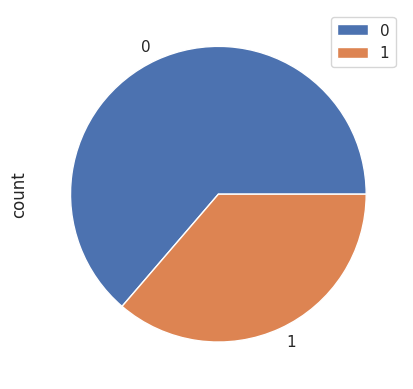

In [88]:
# see if the titanic survived (target) is balanced
print(y_train.value_counts(normalize=True))
y_train.value_counts().plot.pie(labels=['0', '1']).legend();

In [89]:
# we can now build our titanic classification model
# is it balanced? no, use class_weight='balanced'
# is it a small dataset? yes, use liblinear for solver
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, confusion_matrix, roc_auc_score

model = LogisticRegression(class_weight='balanced', solver='liblinear')
model.fit(X_train.drop(drop_features, axis=1), y_train)
predictions = model.predict(X_test.drop(drop_features, axis=1))
tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

rocauc_score = roc_auc_score(y_test, predictions)

print(f'Training Score: {model.score(X_train.drop(drop_features, axis=1), y_train)}')
print(f'Test Score: {model.score(X_test.drop(drop_features, axis=1), y_test)}')

# what is our accuracy? (tn + tp / (total length of our data))
print(f'Test Accuracy (tn + tp / (total length of our data)): {(tn + tp) / (tn + fp + fn + tp)}')
print(f'Roc-Auc Score: {rocauc_score}')

print()
print(confusion_matrix(y_test, predictions))

Training Score: 0.7767584097859327
Test Score: 0.7865853658536586
Test Accuracy (tn + tp / (total length of our data)): 0.7865853658536586
Roc-Auc Score: 0.7818538647342995

[[151  33]
 [ 37 107]]


In [90]:
# what features get the highest accuracy
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, confusion_matrix, roc_auc_score

# vt_keepers = np.array(['pclass' 'sex' 'age' 'sibsp' 'parch' 'embarked_S' 'cat_home_1'])
mi_keepers = np.array(['sex', 'pclass', 'parch', 'age'])
b3_keepers = np.array(['sex', 'age', 'pclass'])
# mt_keepers = np.array(['pclass' 'sex'])
cw_keepers = np.array(['sex', 'pclass'])
pc_keepers = np.array(['pclass'])
sx_keepers = np.array(['sex'])
am_keepers = np.array(['adult_male'])

k_list = {'variance threshold': vt_keepers,
          'k best': kb_keepers,
          'recursive feature': rf_keepers,
          'mututal information': mi_keepers,
          'big 3': b3_keepers,
          'select from model': mt_keepers,
          'corrwith': cw_keepers,
          'pclass': pc_keepers,
          'sex': sx_keepers,
          'adult male': am_keepers}

# keepers = mi_keepers.tolist()

train_scores= {}
test_scores = {}

for k, v in k_list.items():
    keepers = v.tolist()

    model = LogisticRegression(class_weight='balanced', solver='liblinear')
    model.fit(X_train[keepers], y_train)
    predictions = model.predict(X_test[keepers])

    print(f'{k}{keepers} Training Score: {model.score(X_train[keepers], y_train)}')
    print(f'{k}{keepers} Test Score: {model.score(X_test[keepers], y_test)}')
    train_scores[k] = model.score(X_train[keepers], y_train)
    test_scores[k] = model.score(X_test[keepers], y_test)
    print()

print(max(train_scores, key=train_scores.get))
print(max(test_scores, key=test_scores.get))

variance threshold['age', 'pclass', 'sibsp', 'parch'] Training Score: 0.6676860346585117
variance threshold['age', 'pclass', 'sibsp', 'parch'] Test Score: 0.7012195121951219

k best['pclass', 'sex', 'embark_town_Southampton', 'cat_home_North America'] Training Score: 0.7737003058103975
k best['pclass', 'sex', 'embark_town_Southampton', 'cat_home_North America'] Test Score: 0.7560975609756098

recursive feature['pclass', 'sex', 'embark_town_Queenstown', 'embark_town_Southampton', 'cat_home_North America'] Training Score: 0.7696228338430173
recursive feature['pclass', 'sex', 'embark_town_Queenstown', 'embark_town_Southampton', 'cat_home_North America'] Test Score: 0.7530487804878049

mututal information['sex', 'pclass', 'parch', 'age'] Training Score: 0.763506625891947
mututal information['sex', 'pclass', 'parch', 'age'] Test Score: 0.7926829268292683

big 3['sex', 'age', 'pclass'] Training Score: 0.7584097859327217
big 3['sex', 'age', 'pclass'] Test Score: 0.7896341463414634

select fro

## Model Evaluation

### Confusion Matrix

In the field of machine learning and specifically the problem of statistical classification, a confusion matrix, also known as an error matrix, is a specific table layout that allows visualization of the performance of an algorithm, typically a supervised learning one (in unsupervised learning it is usually called a matching matrix)... It is a special kind of contingency table, with two dimensions ("actual" and "predicted"), and identical sets of "classes" in both dimensions (each combination of dimension and class is a variable in the contingency table). They provide our True Negatives, False Positives, False Negatives, and True Positives, from which we derive Accuracy, Precision, and Recall.

https://en.wikipedia.org/wiki/Confusion_matrix

In [91]:
# Confusion Matrix

tn, fp, fn, tp = confusion_matrix(y_test,predictions).ravel()
print('Confusion Matrix')
print(confusion_matrix(y_test, predictions))
print()
print('Here is what the numbers represent')
print('''
                 predicted
                   |  0  |  1
           --------------------
           class 0 | TN  |  FP
  actual   --------------------
           class 1 | FN  |  TP
''')

Confusion Matrix
[[154  30]
 [ 40 104]]

Here is what the numbers represent

                 predicted
                   |  0  |  1
           --------------------
           class 0 | TN  |  FP
  actual   --------------------
           class 1 | FN  |  TP



### Underfitting / Overfitting

* Test scores higher than training scores? Underfitting if large, not using all of the signal in your data
* Train scores higher than test scores? Overfitting if large, memorizing data

### Bias / Variance

Variance: Captures how much your classifier changes if you train on a different training set. How "over-specialized" is your classifier to a particular training set (overfitting)? If we have the best possible model for our training data, how far off are we from the average classifier?

Bias: What is the inherent error that you obtain from your classifier even with infinite training data? This is due to your classifier being "biased" to a particular kind of solution (e.g. linear classifier). In other words, bias is inherent to your model.

Noise: How big is the data-intrinsic noise? This error measures ambiguity due to your data distribution and feature representation. You can never beat this, it is an aspect of the data.

* https://www.cs.cornell.edu/courses/cs4780/2018fa/lectures/lecturenote12.html
* https://www.cs.cornell.edu/courses/cs4780/2018fa/lectures/lecturenote12.html
* https://www.cs.cornell.edu/courses/cs4780/2018fa/

In statistics and machine learning, the bias–variance tradeoff is the property of a model that the variance of the parameter estimates across samples can be reduced by increasing the bias in the estimated parameters. The bias–variance dilemma or bias–variance problem is the conflict in trying to simultaneously minimize these two sources of error that prevent supervised learning algorithms from generalizing beyond their training set.

https://en.wikipedia.org/wiki/Bias%E2%80%93variance_tradeoff

<img src='https://www.kdnuggets.com/wp-content/uploads/bias-and-variance.jpg' alt='bias variance tradeoff' />

Please read the article responsible for the image:

https://www.kdnuggets.com/2016/08/bias-variance-tradeoff-overview.html

### Training Testing Errors Example

$E[(\hat{y} - y)^2] = E[(\hat{y} - E[\hat{y})^2] + (E[\hat{y}] - y)^2$
<br />MSE = Variance + Bias^2
* where y = given y, (ground truth)
* $\hat{y}$ = prediction
* $E[\hat{y}]$ = expected value or average of predictions
* error = $\frac{fp + fn}{total}$
* Bias = error in training, hi error in both training and testing
* Variance = range of predictions on test dataset, how much an estimate of the target function will change if different data was is, high variance - high test error
* Low Bias and High Variance = Overfitting
* High Bias = Underfitting

https://towardsdatascience.com/understanding-the-bias-variance-tradeoff-165e6942b229

<table width='50%' style='margin-right: 100%'>
    <tr>
        <td>Training Error</td>
        <td>1%</td>
        <td>15%</td>
        <td>16%</td>
        <td>1%</td>
    </tr>
    <tr>
        <td>Testing Error</td>
        <td>15%</td>
        <td>16%</td>
        <td>28%</td>
        <td>1%</td>
    </tr>
    <tr>
        <td></td>
        <td>lo bias</td>
        <td>hi bias</td>
        <td>hi bias</td>
        <td>lo bias</td>
    </tr>
    <tr>
        <td></td>
        <td>hi var</td>
        <td>lo var</td>
        <td>hi var</td>
        <td>lo var</td>
    </tr>
</table>

* https://www.mastersindatascience.org/learning/difference-between-bias-and-variance/
* https://www.bmc.com/blogs/bias-variance-machine-learning/

To summarize, in this article, we learned that an ideal model would be one where both the bias error and the variance error are low. However, we should always aim for a model where the model score for the training data is as close as possible to the model score for the testing data.

That’s where we figured out how to choose a model that is not too complex (High variance and low bias) which would lead to overfitting and nor too simple(High Bias and low variance) which would lead to underfitting.

* https://www.analyticsvidhya.com/blog/2020/08/bias-and-variance-tradeoff-machine-learning/
* https://medium.com/analytics-vidhya/a-simple-guide-to-bias-variance-trade-off-part-1-2418229c78e0

### The Classification Report

Both the titanic and cancer datasets weren't as balanced as they could be but to appreciate the implications of an imbalanced dataset, consider a fraudualent credit card dataset where there may be a 1 (for fraudulent activity) per 1000 0s of normal activity. We wouldn't need to build a predictive model to make correct predictions 99% of the time. The data itself lets us do that. We need metrics that tell us that the model we build is learning about the relevant data and that it predicts what it is suppose to predict. This gets back to our Precision Recall Tradeoff.

**Precision**: The sum of observations correctly classified as positive out of the total observations classified as positive. From the formula, tp / (tp + fp), we can see we want to mimimize fp (false positives), or type I errors, which is sounding an alarm when there is no fire.

**Recall**: The sum of observations correctly classified as positive out of the total actual positives. From the forumula, tp / (tp + fn), we can see we want to minimize fn (false negatives), or type II errors, which is not sounding an alarm when there is a fire.

In [92]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         0.0       0.79      0.84      0.81       184
         1.0       0.78      0.72      0.75       144

    accuracy                           0.79       328
   macro avg       0.78      0.78      0.78       328
weighted avg       0.79      0.79      0.79       328



In [93]:
tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
print(tn, fp, fn, tp)
print('precision 0:', round(tn/(tn+fn), 2))
print('precision 1:', round(tp/(tp+fp), 2))
print('recall 0:', round(tn/(tn+fp), 2))
print('recall 1:', round(tp/(tp+fn), 2))

154 30 40 104
precision 0: 0.79
precision 1: 0.78
recall 0: 0.84
recall 1: 0.72


We know about accuracy, precision, and recall and we've talked about f1-score as being the harmonic mean of precision and recall (f1 score = 2 * (precision * recall) / (precision + recall)).

* support: the number of observations labeled 0 or 1 (remember the pie chart we made of the target?)
* macro avg: the average between the two classes (e.g. (prec 0 + prec 1) / 2
* weighted avg: the average between the two classes taking into account the number of their observations (e.g. ((prec0 * score0) + (prec 1 * score1)) / total)

A classification report provides a little more information by providing metrics for each class. For example, for class 0, our recall is higher than our precision, which tells us that there are fewer false negatives than false positives in class 0.

### Precision / Recall

In pattern recognition, information retrieval and classification (machine learning), precision (also called positive predictive value) is the fraction of relevant instances among the retrieved instances, while recall (also known as sensitivity) is the fraction of relevant instances that were retrieved. Both precision and recall are therefore based on relevance... Accuracy can be a misleading metric for imbalanced data sets. Consider a sample with 95 negative and 5 positive values. Classifying all values as negative in this case gives 0.95 accuracy score.

https://en.wikipedia.org/wiki/Precision_and_recall

In cases of imbalanced data, precision, recall, and f1 score become useful metrics. Precision tells us the proportion of data that was predicted was actually predicted correctly. Recall, also known as the True Positive Rate, is the probability that an actual positive will be predicted to be positive.

Precision (also called positive predictive value) is the fraction of relevant instances among the retrieved instances, while recall (also known as sensitivity) is the fraction of relevant instances that were retrieved. Both precision and recall are therefore based on relevance.

https://en.wikipedia.org/wiki/Precision_and_recall

<img src='https://miro.medium.com/v2/resize:fit:640/format:webp/1*GM10sFuFBAbhwBt2scuP1g.png' alt='precision recall tradeoff' />

https://datascience-george.medium.com/the-precision-recall-trade-off-aa295faba140

* Precision - What did you correctly predict?
* Recall - What did you correctly identify from the acutal data?
* F1 (harmonic mean) - (2x(RecallxPrecision))/(Recall+Precision)

## Fine Tuning

### Grid Search

The traditional way of performing hyperparameter optimization has been grid search, or a parameter sweep, which is simply an exhaustive searching through a manually specified subset of the hyperparameter space of a learning algorithm. A grid search algorithm must be guided by some performance metric, typically measured by cross-validation on the training set or evaluation on a hold-out validation set.

https://en.wikipedia.org/wiki/Hyperparameter_optimization#Grid_search



### Hyperparameter

In machine learning, a hyperparameter is a parameter whose value is used to control the learning process. By contrast, the values of other parameters (typically node weights) are derived via training. Hyperparameters can be classified as model hyperparameters, that cannot be inferred while fitting the machine to the training set because they refer to the model selection task, or algorithm hyperparameters, that in principle have no influence on the performance of the model but affect the speed and quality of the learning process.

https://en.wikipedia.org/wiki/Hyperparameter_(machine_learning)

### Cross Validation

Cross-validation, sometimes called rotation estimation or out-of-sample testing, is any of various similar model validation techniques for assessing how the results of a statistical analysis will generalize to an independent data set. Cross-validation is a resampling method that uses different portions of the data to test and train a model on different iterations.

https://en.wikipedia.org/wiki/Cross-validation_(statistics)


In [94]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

feats_for_model = ['sex', 'age', 'pclass']

hyperparameters = {
            'penalty': ['l2', 'l1', 'elasticnet'],
            'C': np.logspace(-4, 4, 10),
            'fit_intercept': [True, False],
            'class_weight': ['balanced', 'None'],
            'solver': ['lbfgs', 'liblinear', 'newton-cholesky']
            }

grid_search = GridSearchCV(estimator = LogisticRegression(),
                           param_grid = hyperparameters,
                           scoring = 'accuracy',
                           cv = 10)

grid_search = grid_search.fit(X_train[feats_for_model], y_train)

best_accuracy = grid_search.best_score_
best_parameters = grid_search.best_params_

print('best accuracy', best_accuracy)
print('best parameters', best_parameters)

best accuracy 0.7808080808080808
best parameters {'C': 0.046415888336127774, 'class_weight': 'balanced', 'fit_intercept': True, 'penalty': 'l1', 'solver': 'liblinear'}


In [95]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

model = LogisticRegression().set_params(**best_parameters) # * args, ** kwargs
model.fit(X_train[feats_for_model], y_train)
predictions = model.predict(X_test[feats_for_model])
print(accuracy_score(y_test, predictions))
print(confusion_matrix(y_test, predictions))

0.7804878048780488
[[161  23]
 [ 49  95]]


### Metrics Summary

* tn = pred 0 actual 0
* fp = pred 1 actual 0
* fn = pred 0 actual 1
* tp = pred 1 actual 1
* acc(uracy) = $\frac{tn + tp}{total}$
* error = $\frac{fp + fn}{total}$
* prev(alence) = $\frac{fn + tp}{total}$
* queue = $\frac{fp + tp}{total}$
* tpr = $\frac{tp}{tp + fn}$
    * true positive rate
    * recall
    * sensitivity
    * prob of detection
    * 1 - fnr
* fnr = $\frac{fn}{tp + fn}$
    * false negative rate
    * type II error
    * 1 - tpr
* tnr = $\frac{tn}{tn + fp}$
    * true negative rate
    * specificity
    * 1 - fpr
* fpr = $\frac{fp}{tn + fp}$
    * false positive rate
    * type I error
    * fall out
    * prob of false claim
    * 1 - tnr
* ppv = $\frac{tp}{tp + fp}$
    * positive predicted value
    * precision
    * 1 - fdr
* fdr = $\frac{fp}{tp + fp}$
    * false discovery rate
    * 1 - ppv
* npv = $\frac{tn}{tn + fn}$
    * negative predicted value
    * 1 - for
* for = $\frac{fn}{tn + fn}$
    * false omission rate
    * 1 - npv
* liklihood ratio+ (lr+) = $\frac{tpr}{fpr}$
    * roc
* liklihood ratio- (lr-) = $\frac{fnr}{tnr}$
* diagnostic odds ratio = $\frac{lr+}{lr-}$
* f1 score = 2 * $\frac{precision-recall}{precision+recall}$
* Youden's J = sensitivity + specificity - 1 = tpr - fpr
* Matthew's Correlation Coefficient = $\frac{(tp*tn)-(fp*tp)}{\sqrt{(tp+fp)(tp+fn)(tn+fp)(tn+fn)}}$
  

In [96]:
# what is the recall? (derive the answer from the confusion matrix)
# tn, fp, fn, tp is given in cell above
# for example false negative rate (fnr) = fn / (fn + tp) so to get the fnr type fn / (fn + tp)

In [97]:
# what is the precision? (derive the answer from the confusion matrix)